In [1]:
from mejiro.lensed_supernova import LensedSupernova
from mejiro.utils import util

In [2]:
lens_population = util.unpickle('sn_lens_population.pkl')

In [3]:
sample = lens_population[2]

In [4]:
sn = LensedSupernova.from_slsim(sample)

In [13]:
from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine

roman = Roman()
kwargs_psf = STPSFEngine.get_roman_psf_kwargs('F129', 1, (2044, 2044), 5, 101, True, '/data/bwedig/mejiro/cached_psfs')

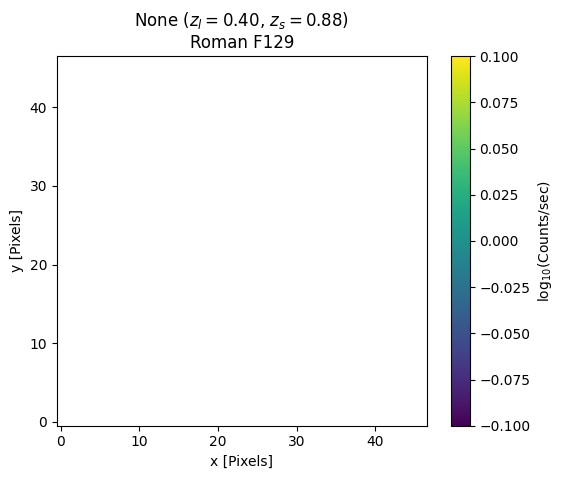

In [14]:
synth = SyntheticImage(sn, roman, 'F129', pieces=True, kwargs_psf=kwargs_psf)
synth.plot()

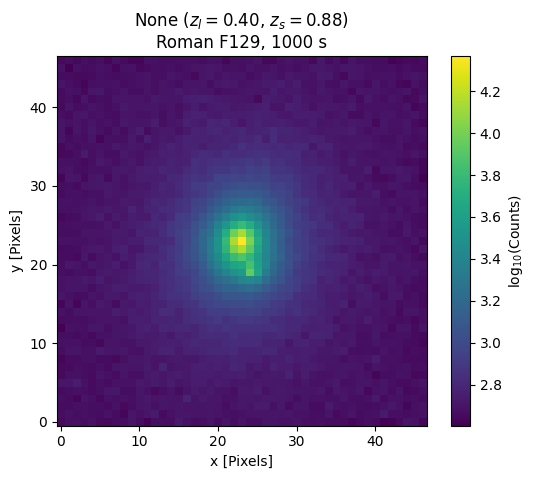

In [7]:
exposure = Exposure(synth, 1000)
exposure.plot()

In [8]:
from copy import deepcopy

sn_with = deepcopy(sn)
sn_with.quick_add()

sn_none = deepcopy(sn)

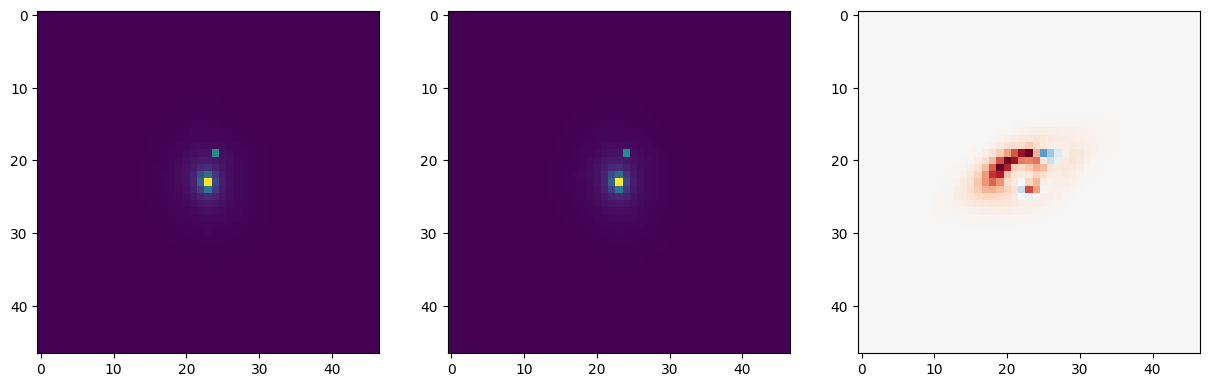

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, LogNorm

synth_none = SyntheticImage(sn_with, roman, 'F129')
synth_with = SyntheticImage(sn_none, roman, 'F129')

_, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(synth_none.data)
ax[1].imshow(synth_with.data)
ax[2].imshow(synth_with.data - synth_none.data, norm=CenteredNorm(), cmap='RdBu_r')
plt.show()

In [15]:
import numpy as np
from tqdm import tqdm

sample_times = np.array([-50, -25, 0, 50, 75, 100, 125, 150])

synths, exposures = [], []

for t in tqdm(sample_times):
    sn.set_observation_time(t, 'F129')
    synth = SyntheticImage(sn, roman, 'F129', kwargs_psf=kwargs_psf)
    exposure = Exposure(synth, 1000)
    synths.append(synth)
    exposures.append(exposure)

100%|██████████| 8/8 [00:01<00:00,  7.48it/s]


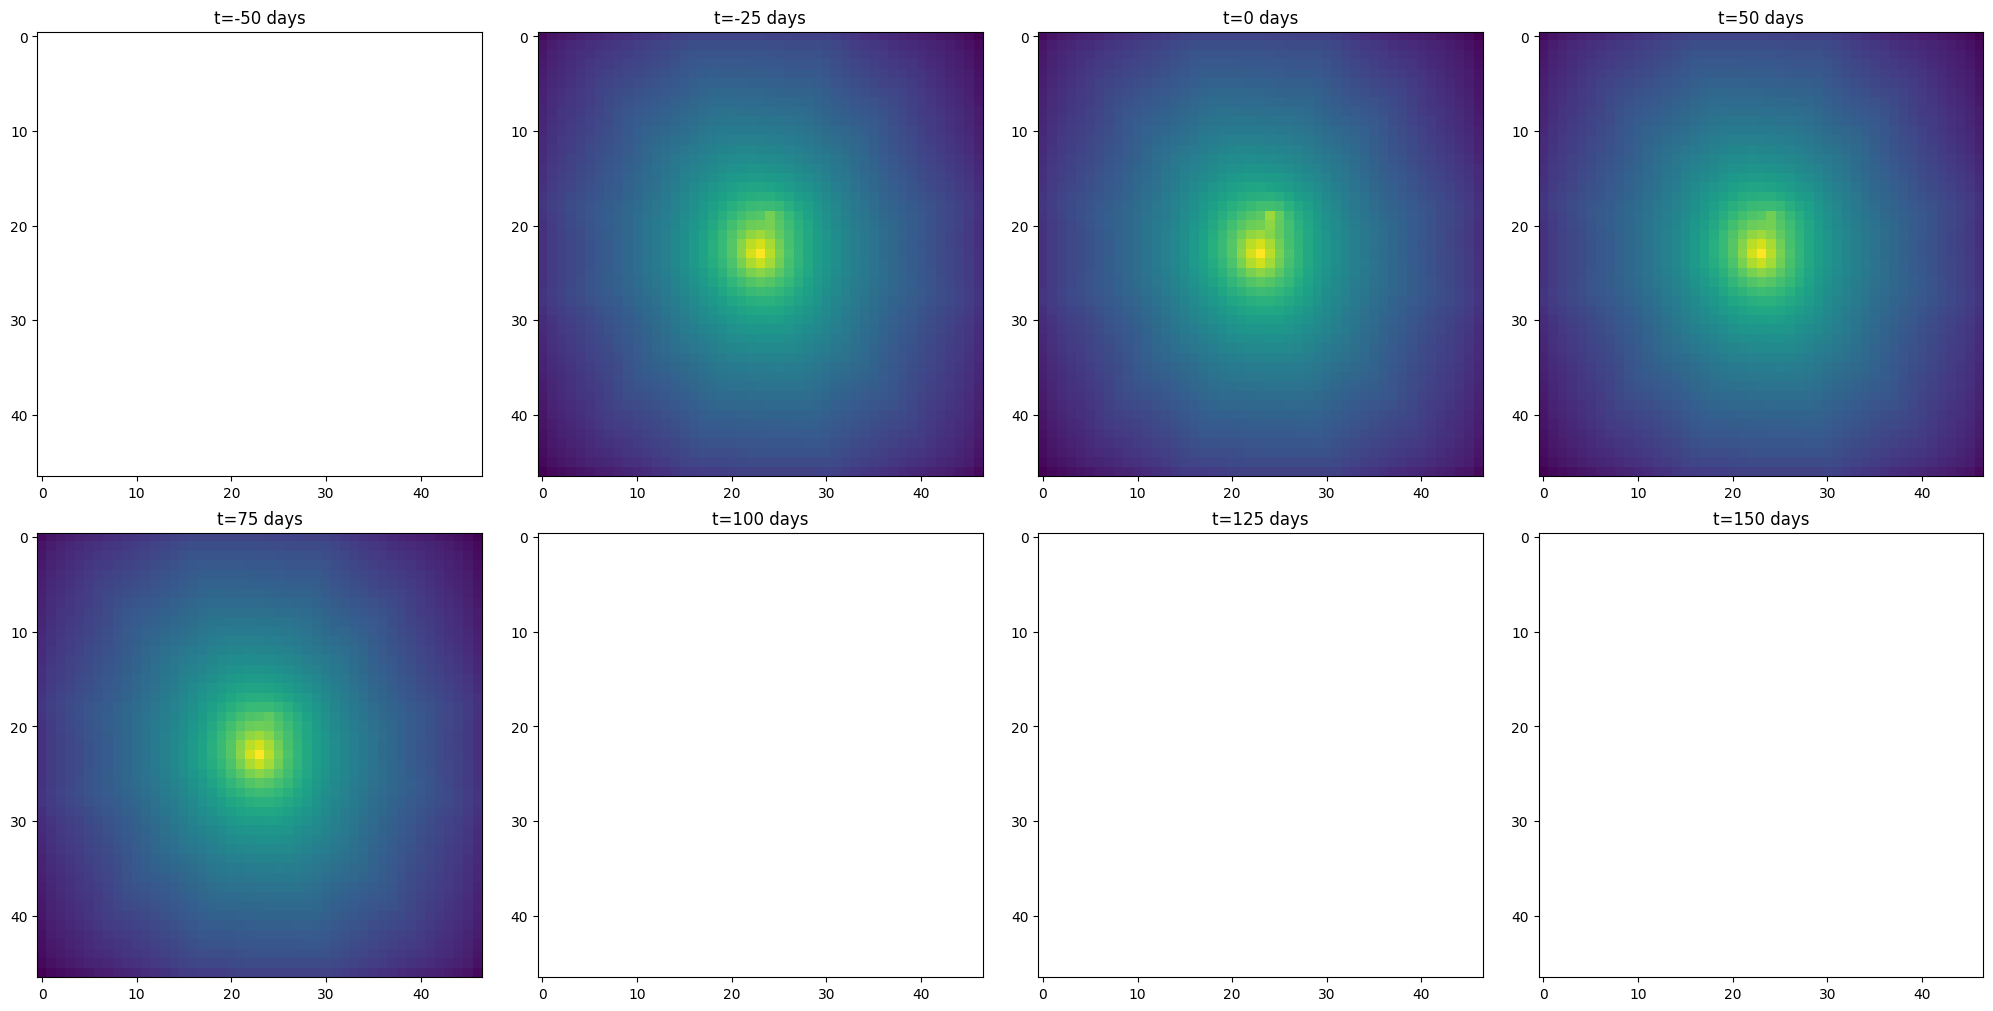

In [19]:
_, ax = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

for i in range(8):
    ax.flatten()[i].imshow(synths[i].data, norm=LogNorm())
    ax.flatten()[i].set_title(f't={sample_times[i]} days')

plt.show()

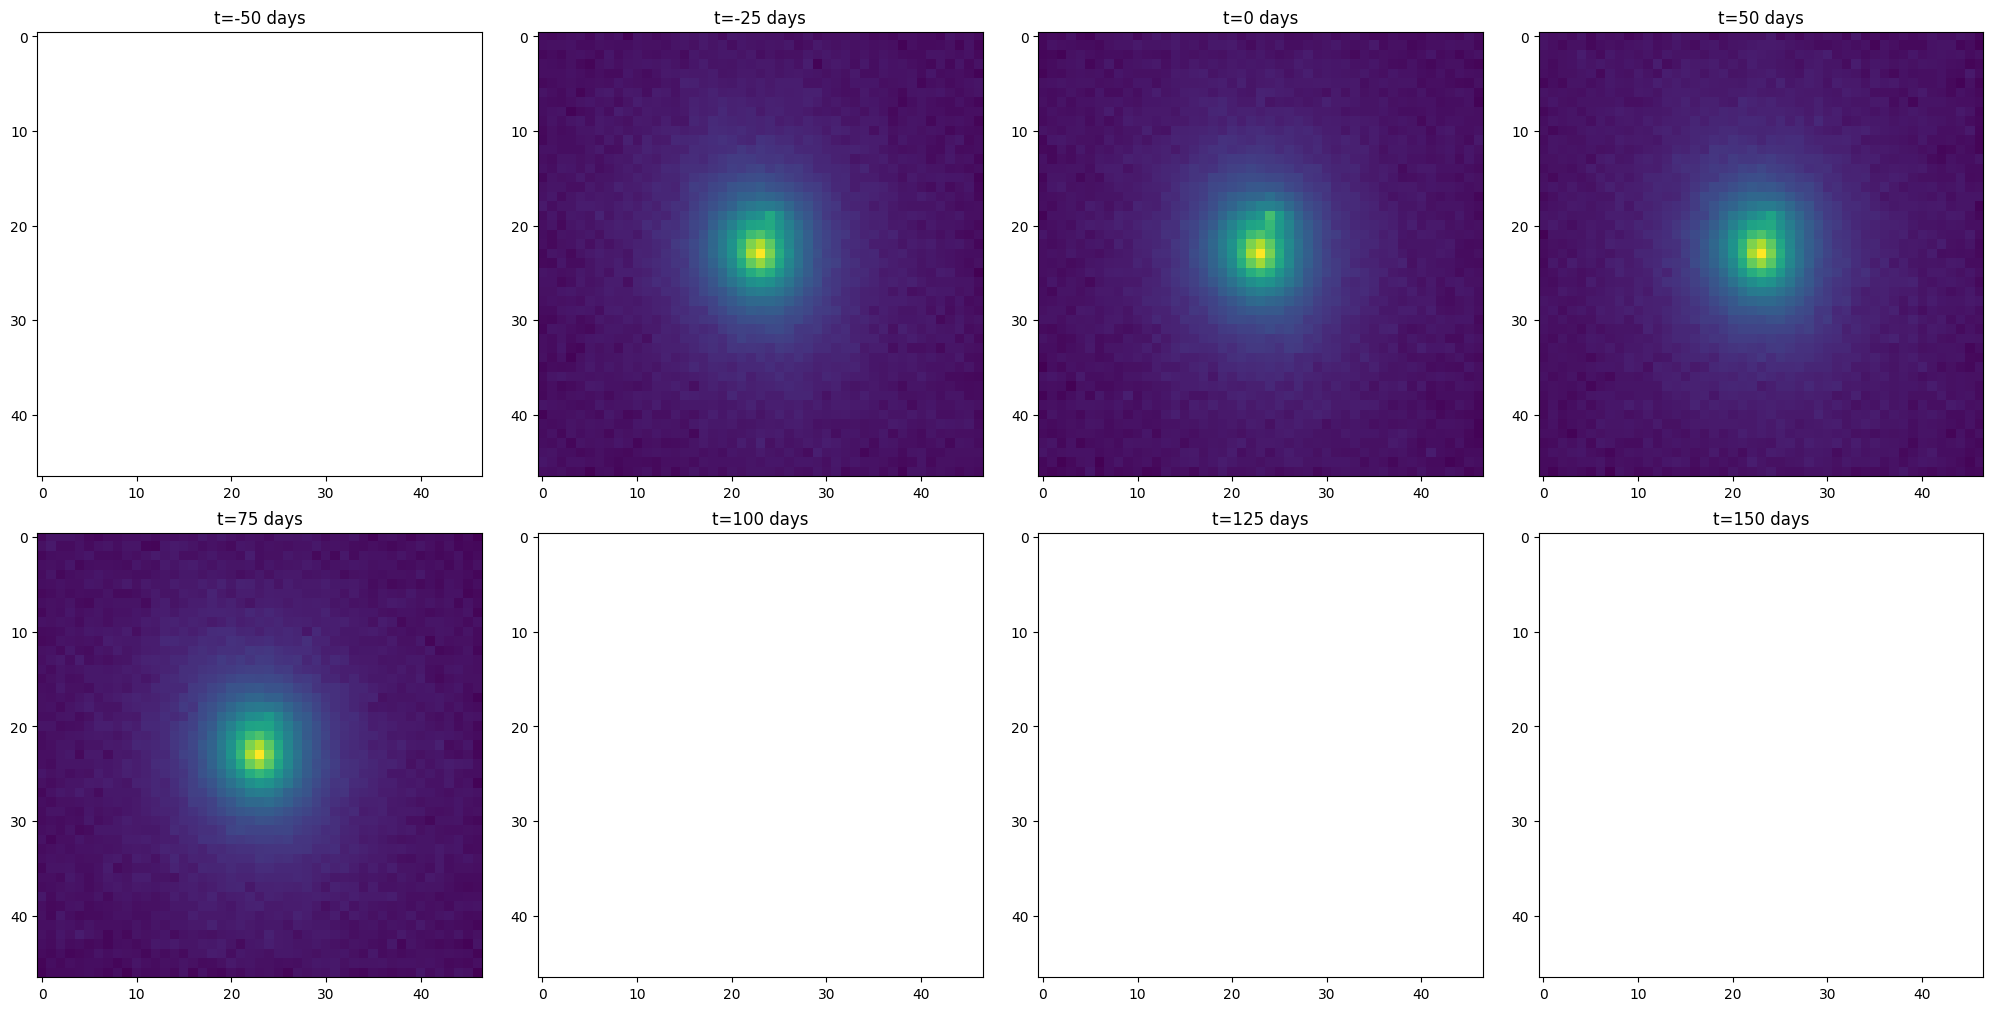

In [30]:
_, ax = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)

for i in range(8):
    ax.flatten()[i].imshow(exposures[i].data, norm=LogNorm())
    ax.flatten()[i].set_title(f't={sample_times[i]} days')

plt.show()

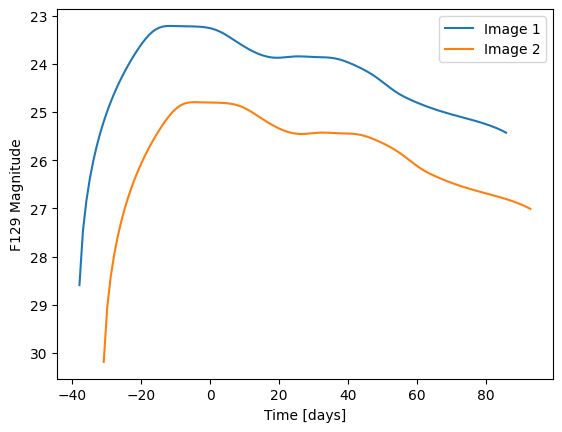

In [29]:
lc = sn.get_light_curve('F129')

plt.plot(lc['time'], lc['magnitudes'][0], label='Image 1')
plt.plot(lc['time'], lc['magnitudes'][1], label='Image 2')
plt.gca().invert_yaxis()
plt.xlabel('Time [days]')
plt.ylabel('F129 Magnitude')
plt.legend()
plt.show()